In [129]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
borrower = pd.read_csv("Borrower.csv")
loan = pd.read_csv("Loan.csv")

In [131]:
loan.head(3)

,loanId,memberId,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus
0,1888978,2305095,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490.0,E3,Current
1,1299695,2610493,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455.0,B3,Current
2,1875016,2491679,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622.0,B2,Current


In [132]:
borrower.head(3)

,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,2305095,NM,10+ years,rent,56471,1,16.80,6,11,9.0,6,14301,49.02,0,19,10,0
1,2610493,WA,2-5 years,rent,55038,0,19.99,22,8,7.0,4,18262,72.40,1,0,0,0
2,2491679,MS,< 1 year,rent,56610,1,14.33,5,8,5.0,5,10799,66.27,0,1,1,0


In [133]:
df = pd.merge(borrower, loan, on="memberId")

df.head()

,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,...,loanId,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus
0,2305095,NM,10+ years,rent,56471,1,16.80,6,11,9.0,...,1888978,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490.0,E3,Current
1,2610493,WA,2-5 years,rent,55038,0,19.99,22,8,7.0,...,1299695,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455.0,B3,Current
2,2491679,MS,< 1 year,rent,56610,1,14.33,5,8,5.0,...,1875016,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622.0,B2,Current
3,2092798,TX,6-9 years,own,54887,1,14.80,12,14,7.0,...,1440478,4/22/2016,homeimprovement,0.0,13053.0,48 months,11.89,343.0,B3,Current
4,2633077,MA,2-5 years,rent,53522,1,10.14,4,21,19.0,...,1124634,2/3/2016,debtconsolidation,0.0,24613.0,60 months,15.13,587.0,A3,Current


In [134]:
df.to_csv("merged_credit_data.csv", index=False)

In [135]:
df.shape

(51798, 27)

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51798 entries, 0 to 51797
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   memberId                  51798 non-null  int64  
 1   residentialState          51798 non-null  object 
 2   yearsEmployment           51798 non-null  object 
 3   homeOwnership             51798 non-null  object 
 4   annualIncome              51798 non-null  int64  
 5   incomeVerified            51798 non-null  int64  
 6   dtiRatio                  51798 non-null  float64
 7   lengthCreditHistory       51798 non-null  int64  
 8   numTotalCreditLines       51798 non-null  int64  
 9   numOpenCreditLines        51301 non-null  float64
 10  numOpenCreditLines1Year   51798 non-null  int64  
 11  revolvingBalance          51798 non-null  int64  
 12  revolvingUtilizationRate  51798 non-null  float64
 13  numDerogatoryRec          51798 non-null  int64  
 14  numDel

In [137]:
df.isnull().sum()

memberId                      0
residentialState              0
yearsEmployment               0
homeOwnership                 0
annualIncome                  0
incomeVerified                0
dtiRatio                      0
lengthCreditHistory           0
numTotalCreditLines           0
numOpenCreditLines          497
numOpenCreditLines1Year       0
revolvingBalance              0
revolvingUtilizationRate      0
numDerogatoryRec              0
numDelinquency2Years          0
numChargeoff1year             0
numInquiries6Mon              0
loanId                        0
date                          0
purpose                       0
isJointApplication          495
loanAmount                  516
term                        578
interestRate                  0
monthlyPayment                0
grade                         0
loanStatus                    0
dtype: int64

In [138]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [139]:
df.fillna("Unknown", inplace=True)

In [140]:
df.drop_duplicates(inplace=True)

In [141]:
df.isnull().sum()

memberId                    0
residentialState            0
yearsEmployment             0
homeOwnership               0
annualIncome                0
incomeVerified              0
dtiRatio                    0
lengthCreditHistory         0
numTotalCreditLines         0
numOpenCreditLines          0
numOpenCreditLines1Year     0
revolvingBalance            0
revolvingUtilizationRate    0
numDerogatoryRec            0
numDelinquency2Years        0
numChargeoff1year           0
numInquiries6Mon            0
loanId                      0
date                        0
purpose                     0
isJointApplication          0
loanAmount                  0
term                        0
interestRate                0
monthlyPayment              0
grade                       0
loanStatus                  0
dtype: int64

In [142]:
df.columns = df.columns.str.strip().str.lower()

In [143]:
df.columns

Index(['memberid', 'residentialstate', 'yearsemployment', 'homeownership',
       'annualincome', 'incomeverified', 'dtiratio', 'lengthcredithistory',
       'numtotalcreditlines', 'numopencreditlines', 'numopencreditlines1year',
       'revolvingbalance', 'revolvingutilizationrate', 'numderogatoryrec',
       'numdelinquency2years', 'numchargeoff1year', 'numinquiries6mon',
       'loanid', 'date', 'purpose', 'isjointapplication', 'loanamount', 'term',
       'interestrate', 'monthlypayment', 'grade', 'loanstatus'],
      dtype='object')

In [144]:
df["numopencreditlines"] = df["numopencreditlines"].fillna(df["numopencreditlines"].median())

df["loanamount"] = df["loanamount"].fillna(df["loanamount"].median())

df["isjointapplication"] = df["isjointapplication"].fillna(0)

In [145]:
df["term"] = df["term"].fillna(df["term"].mode()[0])

In [146]:
df["date"] = pd.to_datetime(df["date"])

<H2>DATA PREPROCESSING</H2>

In [147]:
df["default"] = df["loanstatus"].apply(
    lambda x: 0 if x in ["Fully Paid", "Current"] else 1
)

In [148]:
df["default"].value_counts()

default
0    46640
1     5158
Name: count, dtype: int64

In [149]:
df.drop(columns=["memberid","loanid","date","loanstatus"], inplace=True)

In [150]:
df.columns

Index(['residentialstate', 'yearsemployment', 'homeownership', 'annualincome',
       'incomeverified', 'dtiratio', 'lengthcredithistory',
       'numtotalcreditlines', 'numopencreditlines', 'numopencreditlines1year',
       'revolvingbalance', 'revolvingutilizationrate', 'numderogatoryrec',
       'numdelinquency2years', 'numchargeoff1year', 'numinquiries6mon',
       'purpose', 'isjointapplication', 'loanamount', 'term', 'interestrate',
       'monthlypayment', 'grade', 'default'],
      dtype='object')

In [151]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    "residentialstate",
    "yearsemployment",
    "homeownership",
    "purpose",
    "term",
    "grade"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [152]:
X = df.drop("default", axis=1)
y = df["default"]

In [153]:
X.head(3)

,residentialstate,yearsemployment,homeownership,annualincome,incomeverified,dtiratio,lengthcredithistory,numtotalcreditlines,numopencreditlines,numopencreditlines1year,...,numdelinquency2years,numchargeoff1year,numinquiries6mon,purpose,isjointapplication,loanamount,term,interestrate,monthlypayment,grade
0,30,1,2,56471,1,16.80,6,11,9.0,6,...,19,10,0,2,0.0,25190.0,2,6.25,490.0,14
1,45,2,2,55038,0,19.99,22,8,7.0,4,...,0,0,0,2,0.0,21189.0,2,10.49,455.0,5
2,23,4,2,56610,1,14.33,5,8,5.0,5,...,1,1,0,2,0.0,29908.0,2,9.11,622.0,4


In [154]:
df.to_csv("preprocessed_credit_data.csv", index=False)

In [155]:
import sqlite3

conn = sqlite3.connect("creditpathai.db")

raw_df = pd.read_csv("merged_credit_data.csv")
processed_df = pd.read_csv("preprocessed_credit_data.csv")

raw_df.to_sql("raw_credit_data", conn, if_exists="replace", index=False)
processed_df.to_sql("processed_credit_data", conn, if_exists="replace", index=False)

conn.close()

In [156]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("creditpathai.db")

df = pd.read_sql("SELECT * FROM processed_credit_data", conn)

df.head(3)

,residentialstate,yearsemployment,homeownership,annualincome,incomeverified,dtiratio,lengthcredithistory,numtotalcreditlines,numopencreditlines,numopencreditlines1year,...,numchargeoff1year,numinquiries6mon,purpose,isjointapplication,loanamount,term,interestrate,monthlypayment,grade,default
0,30,1,2,56471,1,16.80,6,11,9.0,6,...,10,0,2,0.0,25190.0,2,6.25,490.0,14,0
1,45,2,2,55038,0,19.99,22,8,7.0,4,...,0,0,2,0.0,21189.0,2,10.49,455.0,5,0
2,23,4,2,56610,1,14.33,5,8,5.0,5,...,1,0,2,0.0,29908.0,2,9.11,622.0,4,0


In [157]:
conn = sqlite3.connect("creditpathai.db")

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';", conn)

print(tables)

                    name
0        raw_credit_data
1  processed_credit_data


In [158]:
raw_df = pd.read_sql("SELECT * FROM raw_credit_data", conn)
raw_df.head(3)

,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,...,loanId,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus
0,2305095,NM,10+ years,rent,56471,1,16.80,6,11,9.0,...,1888978,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490.0,E3,Current
1,2610493,WA,2-5 years,rent,55038,0,19.99,22,8,7.0,...,1299695,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455.0,B3,Current
2,2491679,MS,< 1 year,rent,56610,1,14.33,5,8,5.0,...,1875016,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622.0,B2,Current


In [159]:
processed_df = pd.read_sql("SELECT * FROM processed_credit_data", conn)
processed_df.head(3)

,residentialstate,yearsemployment,homeownership,annualincome,incomeverified,dtiratio,lengthcredithistory,numtotalcreditlines,numopencreditlines,numopencreditlines1year,...,numchargeoff1year,numinquiries6mon,purpose,isjointapplication,loanamount,term,interestrate,monthlypayment,grade,default
0,30,1,2,56471,1,16.80,6,11,9.0,6,...,10,0,2,0.0,25190.0,2,6.25,490.0,14,0
1,45,2,2,55038,0,19.99,22,8,7.0,4,...,0,0,2,0.0,21189.0,2,10.49,455.0,5,0
2,23,4,2,56610,1,14.33,5,8,5.0,5,...,1,0,2,0.0,29908.0,2,9.11,622.0,4,0


In [160]:
pd.read_sql("SELECT COUNT(*) FROM raw_credit_data", conn)

,COUNT(*)
0,51798


In [161]:
pd.read_sql("SELECT COUNT(*) FROM processed_credit_data", conn)

,COUNT(*)
0,51798


In [162]:
conn.close()

In [163]:
df.shape

(51798, 24)

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51798 entries, 0 to 51797
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   residentialstate          51798 non-null  int64  
 1   yearsemployment           51798 non-null  int64  
 2   homeownership             51798 non-null  int64  
 3   annualincome              51798 non-null  int64  
 4   incomeverified            51798 non-null  int64  
 5   dtiratio                  51798 non-null  float64
 6   lengthcredithistory       51798 non-null  int64  
 7   numtotalcreditlines       51798 non-null  int64  
 8   numopencreditlines        51798 non-null  float64
 9   numopencreditlines1year   51798 non-null  int64  
 10  revolvingbalance          51798 non-null  int64  
 11  revolvingutilizationrate  51798 non-null  float64
 12  numderogatoryrec          51798 non-null  int64  
 13  numdelinquency2years      51798 non-null  int64  
 14  numcha

In [165]:
df.describe()

,residentialstate,yearsemployment,homeownership,annualincome,incomeverified,dtiratio,lengthcredithistory,numtotalcreditlines,numopencreditlines,numopencreditlines1year,...,numchargeoff1year,numinquiries6mon,purpose,isjointapplication,loanamount,term,interestrate,monthlypayment,grade,default
count,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000,...,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000,51798.000000
mean,20.797598,1.981872,0.967161,54720.074346,0.685857,17.301243,10.888027,14.996042,11.260365,7.588440,...,1.231302,1.445693,2.386830,0.050660,20658.816817,1.036565,10.992477,552.624059,5.304606,0.099579
std,14.085109,1.405188,0.830025,3171.292733,0.464178,5.091107,10.632168,4.013006,3.761745,3.404503,...,3.112129,3.284405,1.167069,0.218254,4703.952607,0.841043,3.906624,165.157402,4.085406,0.299441
min,0.000000,0.000000,0.000000,38328.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1908.000000,0.000000,4.020000,44.000000,0.000000,0.000000
25%,8.000000,1.000000,0.000000,52656.250000,0.000000,13.860000,4.000000,12.000000,9.000000,5.000000,...,0.000000,0.000000,2.000000,0.000000,17502.000000,0.000000,8.000000,434.000000,2.000000,0.000000
50%,19.000000,2.000000,1.000000,54787.000000,1.000000,17.260000,6.000000,15.000000,11.000000,7.000000,...,0.000000,0.000000,2.000000,0.000000,20654.000000,1.000000,10.480000,533.000000,5.000000,0.000000
75%,32.000000,3.000000,2.000000,56857.000000,1.000000,20.720000,15.000000,18.000000,14.000000,10.000000,...,1.000000,1.000000,2.000000,0.000000,23754.750000,2.000000,13.460000,654.000000,8.000000,0.000000
max,48.000000,4.000000,2.000000,69553.000000,1.000000,38.060000,40.000000,32.000000,29.000000,26.000000,...,20.000000,19.000000,6.000000,1.000000,41769.000000,3.000000,31.700000,1524.000000,14.000000,1.000000


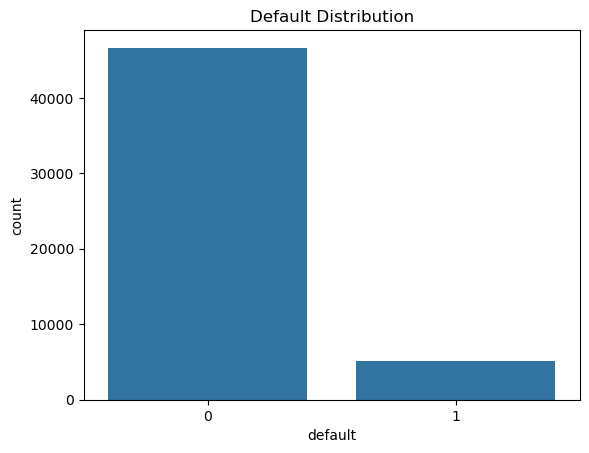

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="default", data=df)
plt.title("Default Distribution")
plt.show()

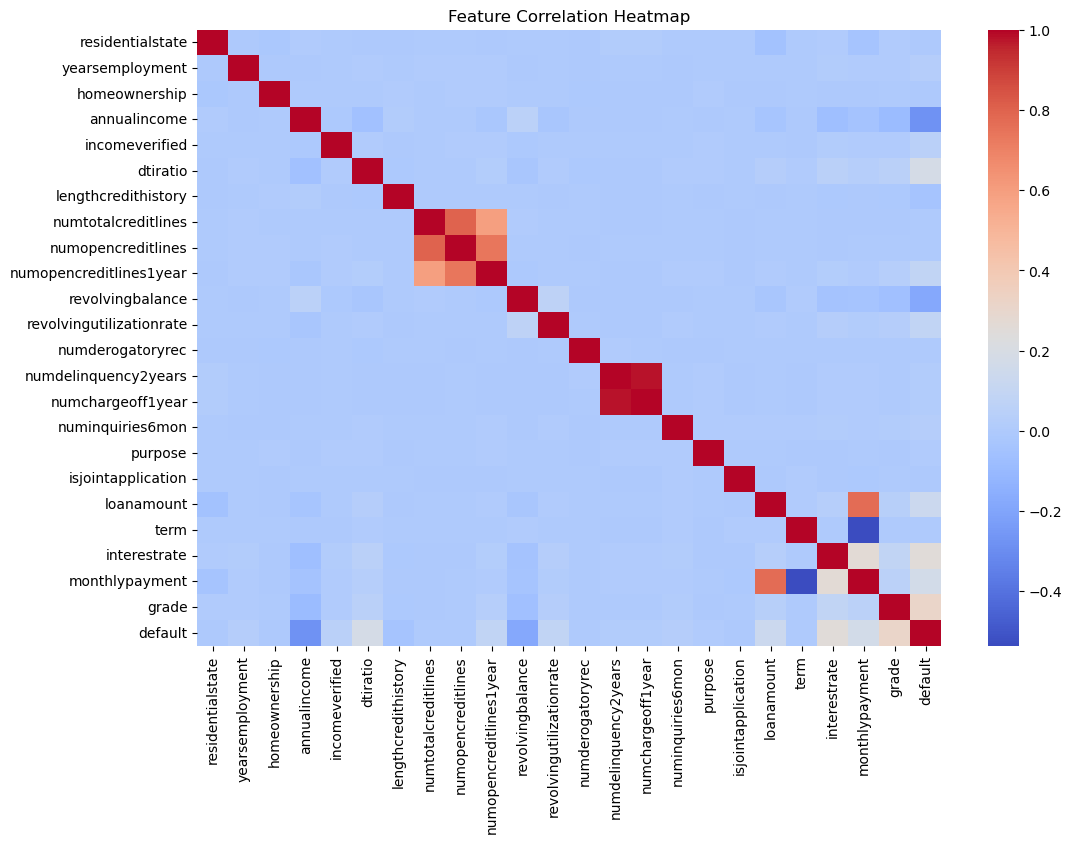

In [167]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

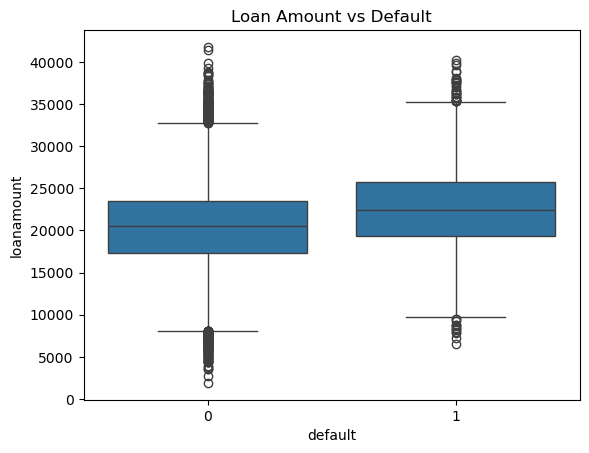

In [168]:
sns.boxplot(x="default", y="loanamount", data=df)

plt.title("Loan Amount vs Default")

plt.show()

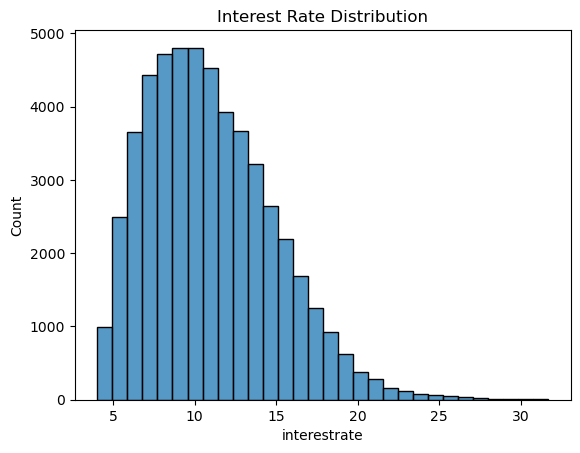

In [169]:
sns.histplot(df["interestrate"], bins=30)

plt.title("Interest Rate Distribution")

plt.show()

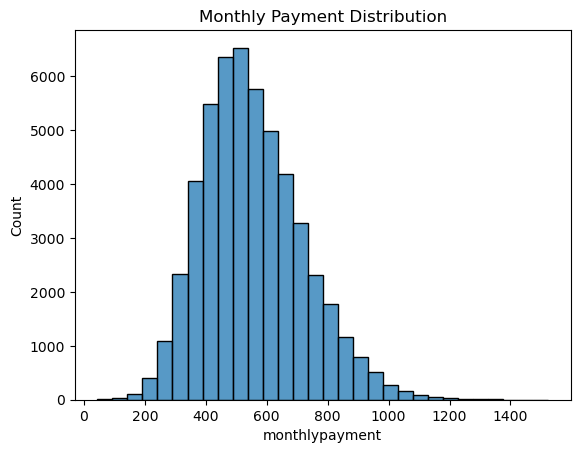

In [170]:
sns.histplot(df["monthlypayment"], bins=30)

plt.title("Monthly Payment Distribution")

plt.show()

In [171]:
X = df.drop("default", axis=1)
y = df["default"]

In [172]:
print("Number of features:", X.shape[1])
print("Feature names:", X.columns.tolist())

Number of features: 23
Feature names: ['residentialstate', 'yearsemployment', 'homeownership', 'annualincome', 'incomeverified', 'dtiratio', 'lengthcredithistory', 'numtotalcreditlines', 'numopencreditlines', 'numopencreditlines1year', 'revolvingbalance', 'revolvingutilizationrate', 'numderogatoryrec', 'numdelinquency2years', 'numchargeoff1year', 'numinquiries6mon', 'purpose', 'isjointapplication', 'loanamount', 'term', 'interestrate', 'monthlypayment', 'grade']


In [173]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [174]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [175]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [176]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [177]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC ROC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9333011583011583
AUC ROC: 0.9206725159906236


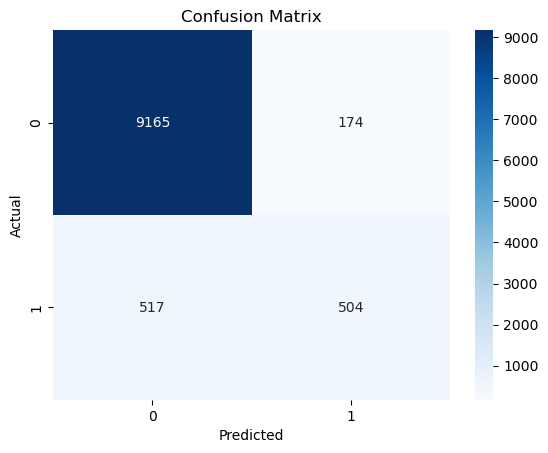

In [178]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [179]:
from xgboost import XGBClassifier

In [180]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [181]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [182]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost AUC ROC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Accuracy: 0.9374517374517375
XGBoost AUC ROC: 0.9306808861011594


In [120]:
!pip install lightgbm


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\velur\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [121]:
from lightgbm import LGBMClassifier

In [122]:
lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 4137, number of negative: 37301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035364 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2080
[LightGBM] [Info] Number of data points in the train set: 41438, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.099836 -> initscore=-2.199049
[LightGBM] [Info] Start training from score -2.199049
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

LGBMClassifier(learning_rate=0.05, max_depth=6, n_estimators=200,
               random_state=42)

In [123]:
y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:,1]

In [124]:
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("LightGBM AUC ROC:", roc_auc_score(y_test, y_prob_lgb))

LightGBM Accuracy: 0.9361969111969112
LightGBM AUC ROC: 0.9298046516252182


In [125]:
results = {
    "Model": ["Logistic Regression", "XGBoost", "LightGBM"],
    "AUC_ROC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgb)
    ]
}

import pandas as pd

pd.DataFrame(results)

,Model,AUC_ROC
0,Logistic Regression,0.920673
1,XGBoost,0.930681
2,LightGBM,0.929805


In [126]:
def recommendation_engine(input_data):
    
    # Step 1: Predict default probability
    prob = xgb_model.predict_proba(input_data)[0][1]

    # Step 2: Get loan amount
    loan_amount = input_data["loanamount"].values[0]

    # Step 3: Calculate expected loss
    expected_loss = prob * loan_amount

    # Step 4: Decision rules
    if expected_loss < 50000:
        priority = "Low"
        action = "Send automated reminder"

    elif expected_loss < 200000:
        priority = "Medium"
        action = "Call borrower and discuss repayment plan"

    elif expected_loss < 500000:
        priority = "High"
        action = "Assign dedicated recovery officer"

    else:
        priority = "Critical"
        action = "Escalate to legal recovery team"

    return {
        "default_probability": float(prob),
        "expected_loss": float(expected_loss),
        "priority": priority,
        "recommended_action": action
    }

In [127]:
sample = X_test.iloc[[0]]

recommendation_engine(sample)

{'default_probability': 0.26673227548599243,
 'expected_loss': 6706.98306709528,
 'priority': 'Low',
 'recommended_action': 'Send automated reminder'}

In [183]:
!pip install joblib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\velur\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [184]:
import joblib
joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']